# **Osnove računalnog vida s OpenCV-jem**

## **Uvod**
Dobrodošli na naprednu radionicu robotike! Danas ćemo naučiti kako iz digitalne slike izvući informacije koje su robotu potrebne za rad (npr. boje i koordinate predmeta, veličinu predmeta i sl.).

### **Što je zapravo digitalna slika?**
Za nas je slika prikaz stvarnosti, ali za računalo je to matrica brojeva (u Pythonu koristimo `numpy` array).

Svaka slika se sastoji od piksela (najmanja jedinica slike).

Standardna slika u boji ima tri sloja (kanala).

##### **PAŽNJA:** Većina programa koristi **RGB** (Red-Green-Blue) sustav, ali OpenCV koristi **BGR** (Blue-Green-Red). To znači da su crvena i plava zamijenjene!


### Koordinatni sustav
U matematici je $(0,0)$ obično dolje lijevo.

U računalnom vidu, ishodište $(0,0)$ je **gornji lijevi kut.**
- X os raste udesno.
- Y os raste prema dolje.

## Instalacija potrebnih paketa

Kopirajte u terminal iduću liniju

## **Primjer 1: Učitavanje i prvi pogled matrice**

U ovom zadatku učitavamo našu prvu sliku.

Cilj je ispisati njezine dimenzije (`shape`) kako bismo vidjeli koliko piksela ima i shvatili da se radi o običnoj listi brojeva.

Također, isprobat ćemo pretvorbu u *Grayscale* (sive tonove) jer je s takvim slikama lakše računati.

Importanje potrebnih paketa

In [1]:
import cv2
import numpy as np 
from matplotlib import pyplot as plt

Učitaj sliku i pretvori ju u Grayscale

In [2]:
img = cv2.imread('slike/robot.png')

#Provjera jeli slika dobro ucitana - nije neophodno
assert img is not None, 'Greška: Slika nije pronađena! Provjeri lokaciju.'

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

Oblik slike + ispis dijela slike

In [3]:
print(f'Original shape: {img.shape}')
print(f'Grayscale shape: {gray.shape}')

print(f"Prikaz slike kao matrice brojeva : \n {gray}")

Original shape: (367, 550, 3)
Grayscale shape: (367, 550)
Prikaz slike kao matrice brojeva : 
 [[ 14   4   0 ...  49  76  98]
 [ 23  12   4 ...  46  59  69]
 [ 74  69  60 ...  93  96  83]
 ...
 [122 121 115 ... 209 210 210]
 [110 116 118 ... 207 207 206]
 [ 91  94 103 ... 204 203 201]]


**Prikaz slike (u Jupyteru)**

Prva zakomentirana linija je standardni način prikazivanja u OpenCV-u, ta funkcija otvara novi prozor s našom slikom, ali to nije povoljno za Jupyter bilježnicu, stoga koristimo funkciju imshow iz modula matplotlib 

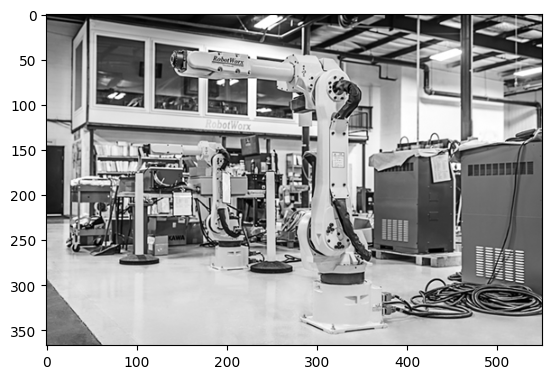

In [4]:
# cv2.imshow('Grayscale', gray)

# Prikaži sliku
plt.imshow(gray, cmap='gray')
plt.show()

#### **Zadatak:** Dobivenu crno-bijelu sliku spremite u folder slike. - guglajte
#### **(Dodatni) Zadatak:** OpenCV ima funkcije za crtanje geometrijskih likova i ubacivanje teksta na sliku. Na neku od prethodnih slika nacrtajte proizvoljne pravce, pravokutnike i kruznice, dodajte neku rijec na sliku i prikazite ju.

## **Primjer 2: HSV filtriranje**

Umjesto da tražimo boju preko BGR-a, prebacujemo se u **HSV prostor** (Hue, Saturation, Value).

Koristimo HSV umjesto RGB (tj. BGR) zato što RGB ne odvaja intenzitet slike od informacije o boji dok HSV to radi - HSV je sličniji ljudskom opisivanju boja.

Hue (nijansa) nam omogućuje da lakše izoliramo specifičnu boju bez obzira na to ima li na slici sjena.

Pomoću slidera (*trackbar*) ćemo pronaći točne granice plave boje i stvoriti **masku** (crno-bijelu sliku gdje je bijelo samo ono što propuštamo).

**Hint:** Hue plave boje je oko 120, a crvene 0 (boja kontrolera je oko 170).

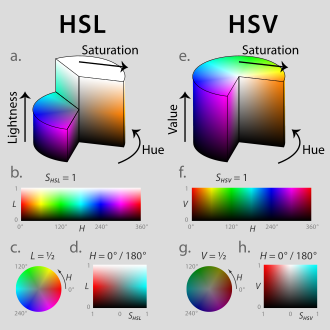

In [ ]:
# Pomoćna funkcija koja ne radi ništa, ali je OpenCV treba za trackbare
def do_nothing(x):
    pass

# Funkcija za brzo postavljanje svih slidera
def set_trackbars(hmin, smin, vmin, hmax, smax, vmax):
    cv2.setTrackbarPos("Hue Low", "Postavke", hmin)
    cv2.setTrackbarPos("Saturation Low", "Postavke", smin)
    cv2.setTrackbarPos("Value Low", "Postavke", vmin)
    cv2.setTrackbarPos("Hue High", "Postavke", hmax)
    cv2.setTrackbarPos("Saturation High", "Postavke", smax)
    cv2.setTrackbarPos("Value High", "Postavke", vmax)

upute_img = np.zeros((250, 500, 3), dtype=np.uint8)
font = cv2.FONT_HERSHEY_SIMPLEX

cv2.putText(upute_img, "UPUTE ZA TIPKOVNICU:", (20, 40), font, 1.3, (255, 255, 255), 2)
cv2.putText(upute_img, "- 'R' : RESET", (20, 80), font, 1.2, (0, 255, 0), 1)
cv2.putText(upute_img, "- 'B' : PLAVA PRESET", (20, 110), font, 1.2, (255, 100, 0), 1)
cv2.putText(upute_img, "- 'C' : CRVENA PRESET", (20, 140), font, 1.2, (0, 0, 255), 1)
cv2.putText(upute_img, "- 'Q' : IZLAZ", (20, 180), font, 1.2, (200, 200, 200), 1)

# 1. Učitaj sliku
img = cv2.imread('slike/predmeti.jpeg')
assert img is not None, 'Greška: Slika nije pronađena! Provjeri putanju.'

# Automatsko skaliranje slike
scale_percent = 0.5
img = cv2.resize(img, None, fx=scale_percent, fy=scale_percent)

# Prebacujemo sliku u HSV format odmah, da ne radimo to u petlji stalno
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 2. Kreiramo kontrolni prozor za slidere
cv2.namedWindow("Postavke", cv2.WINDOW_NORMAL)
cv2.startWindowThread()
cv2.resizeWindow("Postavke", 500, 600)

# Kreiramo 6 slidera za HSV (Donja i Gornja granica)
# Hue ide do 179 u OpenCV-u, Saturation i Value do 255
cv2.createTrackbar("Hue Low", "Postavke", 0, 179, do_nothing)
cv2.createTrackbar("Saturation Low", "Postavke", 0, 255, do_nothing)
cv2.createTrackbar("Value Low", "Postavke", 0, 255, do_nothing)
cv2.createTrackbar("Hue High", "Postavke", 179, 179, do_nothing)
cv2.createTrackbar("Saturation High", "Postavke", 255, 255, do_nothing)
cv2.createTrackbar("Value High", "Postavke", 255, 255, do_nothing)

while True:
    cv2.imshow("Postavke", upute_img)

    # Očitaj trenutne vrijednosti sa slidera
    lh = cv2.getTrackbarPos("Hue Low", "Postavke")
    ls = cv2.getTrackbarPos("Saturation Low", "Postavke")
    lv = cv2.getTrackbarPos("Value Low", "Postavke")
    uh = cv2.getTrackbarPos("Hue High", "Postavke")
    us = cv2.getTrackbarPos("Saturation High", "Postavke")
    uv = cv2.getTrackbarPos("Value High", "Postavke")

    # Definiraj opsege boja na temelju slidera
    lower_hsv = np.array([lh, ls, lv])
    upper_hsv = np.array([uh, us, uv])

    # 3. Kreiraj masku (samo plavi dijelovi postaju bijeli, ostalo crno)
    mask = cv2.inRange(hsv, lower_hsv, upper_hsv)

    # Primijeni masku na originalnu sliku da vidimo samo izoliranu boju
    result = cv2.bitwise_and(img, img, mask=mask)

    # Prikaz prozora
    cv2.imshow("Originalna slika", img)
    cv2.imshow("Maska (Binary)", mask)
    cv2.imshow("Rezultat (Izolirano)", result)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'):
        break
    elif key == ord('r'):
        set_trackbars(0, 0, 0, 179, 255, 255)
    elif key == ord('b'):
        set_trackbars(100, 100, 45, 130, 255, 255)
    elif key == ord('c'):
        set_trackbars(165, 100, 45, 179, 255, 255)
    

# Zatvori sve prozore i oslobodi memoriju
cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/andrija/Desktop/crta_radionice/opencv-radionice/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/andrija/Desktop/crta_radionice/opencv-radionice/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/andrija/Desktop/crta_radionice/opencv-radionice/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/andrija/Desktop/crta_radionice/opencv-radionice/.venv/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some 

## **Primjer 3: Detekcija rubova**

Kako bi robot prepoznao kutiju ili rub stola, moramo pronaći linije.

Koristit ćemo **Canny algoritam**. On traži mjesta na slici gdje se intenzitet boje naglo mijenja.

Prije toga ćemo primijeniti *blur* (zamućenje) kako bismo uklonili "šum" (sitne nepravilnosti koje bi algoritam krivo protumačio kao rubove).


In [17]:
def do_nothing(x):
    pass

# Učitaj sliku (npr. slika UR robotske ruke ili neke kutije)
img = cv2.imread('slike/predmeti.jpeg')
assert img is not None, 'Greška: Slika nije pronađena! Provjeri putanju.'

# 1. Priprema: Smanji sliku i pretvori u sivu (Gray)
scale = 0.2
img = cv2.resize(img, None, fx=scale, fy=scale)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Kreiranje prozora i slidera za Canny pragove
cv2.namedWindow("Postavke")
# cv2.startWindowThread()

cv2.createTrackbar("Canny Low", "Postavke", 50, 500, do_nothing)
cv2.createTrackbar("Canny High", "Postavke", 150, 500, do_nothing)
cv2.createTrackbar("Sobel Dx", "Postavke", 1, 3, do_nothing)
cv2.createTrackbar("Sobel Dy", "Postavke", 1, 3, do_nothing)
cv2.createTrackbar("Blur Size", "Postavke", 2, 10, do_nothing) # Za Gaussian Blur

print("Pomiči slidere da izoliraš rubove objekta. 'Q' za izlaz.")

while True:
    # Očitaj vrijednosti
    canny_low = cv2.getTrackbarPos("Canny Low", "Postavke")
    canny_high = cv2.getTrackbarPos("Canny High", "Postavke")
    sobel_dx = cv2.getTrackbarPos("Sobel Dx", "Postavke")
    sobel_dy = cv2.getTrackbarPos("Sobel Dy", "Postavke")
    blur_val = cv2.getTrackbarPos("Blur Size", "Postavke")

    # Obje vrijednosti ne smiju biti 0, inače dobivamo grešku
    if sobel_dx == sobel_dy == 0:
        cv2.setTrackbarPos("Sobel Dx", "Postavke", 1)
        cv2.setTrackbarPos("Sobel Dy", "Postavke", 1)
        sobel_dx = 1
        sobel_dy = 1
    
    # 3. Obrada
    # Prvo blurramo da maknemo sitne smetnje
    # Napomena, blur_val mora biti neparan zbog načina rada Gaussian Blur algoritma
    blurred = cv2.GaussianBlur(gray, (2*blur_val+1, 2*blur_val+1), 0)
    
    # Canny i Sobel algoritmi
    canny = cv2.Canny(blurred, canny_low, canny_high)
    sobelxy = cv2.Sobel(blurred, ddepth=cv2.CV_64F, dx=sobel_dx, dy=sobel_dy, ksize=5)

    # Prikaz (Original vs Rubovi)
    cv2.imshow("Postavke", np.ones((1, 500, 3), dtype=np.uint8))
    cv2.imshow("Original (Sivo)", blurred)
    cv2.imshow("Canny Detekcija", canny)
    cv2.imshow("Sobel Detekcija", sobelxy)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break


cv2.destroyAllWindows()
cv2.waitKey(1)

Pomiči slidere da izoliraš rubove objekta. 'Q' za izlaz.


-1

## **Primjer 4: Detektiranje i praćenje loptice uživo**
